In [7]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Load cleaned data
df = pd.read_csv("data/cleaned/cleaned_border_crossing.csv")
df["date"] = pd.to_datetime(df["date"])

print(df.shape)
df.head()

(49993, 11)


,port_name,state,port_code,border,date,measure,value,latitude,longitude,point,month
0,Richford,Vermont,203,US-Canada Border,2026-01-01,Personal Vehicles,4050,45.011740,-72.588559,POINT (-72.588559 45.01174),1
1,Naco,Arizona,2603,US-Mexico Border,2026-01-01,Trucks,208,31.334084,-109.948413,POINT (-109.948413 31.334084),1
2,Naco,Arizona,2603,US-Mexico Border,2026-01-01,Truck Containers Empty,103,31.334084,-109.948413,POINT (-109.948413 31.334084),1
3,Sumas,Washington,3009,US-Canada Border,2026-01-01,Rail Containers Empty,338,49.002388,-122.264805,POINT (-122.264805 49.002388),1
4,Vanceboro,Maine,105,US-Canada Border,2026-01-01,Rail Containers Loaded,5908,45.568761,-67.428541,POINT (-67.428541 45.568761),1


In [8]:
# Total crossings per port
port_total = df.groupby("port_name")["value"].sum().rename("total_crossings")

# Average monthly crossings per port
port_avg = df.groupby("port_name")["value"].mean().rename("avg_crossings")

# Most common measure type per port
port_measure = df.groupby("port_name")["measure"].agg(lambda x: x.value_counts().index[0]).rename("top_measure")

# Which border the port is on
port_border = df.groupby("port_name")["border"].first().rename("border")

# Which state the port is in
port_state = df.groupby("port_name")["state"].first().rename("state")

# Combine into one dataframe
port_df = pd.concat([port_total, port_avg, port_border, port_state, port_measure], axis=1).reset_index()

print(port_df.shape)
port_df.head(10)

(111, 6)


,port_name,total_crossings,avg_crossings,border,state,top_measure
0,Alcan,655149,1742.417553,US-Canada Border,Alaska,Personal Vehicle Passengers
1,Alexandria Bay,8853146,20352.059770,US-Canada Border,New York,Trucks
2,Algonac,376783,4095.467391,US-Canada Border,Michigan,Personal Vehicles
3,Ambrose,11299,66.857988,US-Canada Border,North Dakota,Personal Vehicles
4,Andrade,11102734,54159.678049,US-Mexico Border,California,Personal Vehicle Passengers
5,Antler,84807,272.691318,US-Canada Border,North Dakota,Trucks
6,Bar Harbor,108803,2266.729167,US-Canada Border,Maine,Personal Vehicles
7,Baudette,1397154,3175.350000,US-Canada Border,Minnesota,Trucks
8,Beecher Falls,690855,1968.247863,US-Canada Border,Vermont,Personal Vehicle Passengers
9,Blaine,40352994,56516.798319,US-Canada Border,Washington,Personal Vehicle Passengers


In [15]:
# Flags rows that represent personal travel vs commercial freight
personal_measures = [
    "Personal Vehicles",
    "Personal Vehicle Passengers",
    "Pedestrians",
    "Bus Passengers",
    "Train Passengers"
]
df["is_personal"] = df["measure"].isin(personal_measures)

personal_ratio = (
    df.groupby("port_name")[["value", "is_personal"]]
    .apply(lambda g: g.loc[g["is_personal"], "value"].sum() / g["value"].sum()
           if g["value"].sum() > 0 else 0, include_groups=False)
    .rename("personal_vehicle_ratio")
)

# Seasonality variance per port
# High variance = strong seasonal swings (tourism/vacation driven)
# Low variance = steady year-round traffic (freight/commuter driven)
seasonality = (
    df.groupby(["port_name", "date"])["value"]
    .sum()
    .reset_index()
    .groupby("port_name")["value"]
    .std()
    .fillna(0)
    .rename("seasonality_variance")
)

# Rebuild port_df with all features
port_df = pd.concat(
    [port_total, port_avg, port_border, port_state, port_measure,
     personal_ratio, seasonality],
    axis=1
).reset_index()

# Encode border AFTER concat so it is not overwritten
port_df["border_encoded"] = (port_df["border"] == "US-Mexico Border").astype(int)

print(port_df.shape)
print(port_df[["port_name", "personal_vehicle_ratio", "seasonality_variance"]].head(10))

# Select all 5 features for clustering
features = port_df[[
    "total_crossings",
    "avg_crossings",
    "border_encoded",
    "personal_vehicle_ratio",
    "seasonality_variance"
]]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print(f"Feature matrix shape: {features_scaled.shape}")

(111, 9)
        port_name  personal_vehicle_ratio  seasonality_variance
0           Alcan                0.875108           9107.915272
1  Alexandria Bay                0.723881          70495.845471
2         Algonac                1.000000           4110.242579
3         Ambrose                0.995929            118.406555
4         Andrade                1.000000          49635.388826
5          Antler                0.834966            531.542184
6      Bar Harbor                1.000000           3037.251160
7        Baudette                0.967069          13513.857854
8   Beecher Falls                0.847114           8090.012289
9          Blaine                0.859152         330211.309607
Feature matrix shape: (111, 5)


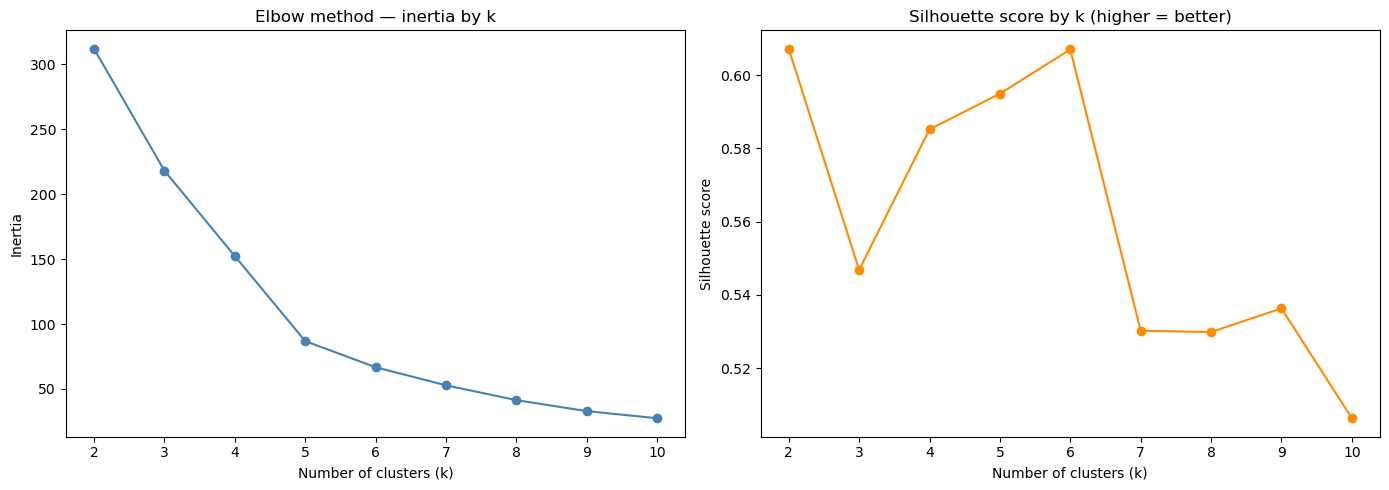

k=2  silhouette=0.6072
k=3  silhouette=0.5468
k=4  silhouette=0.5852
k=5  silhouette=0.5949
k=6  silhouette=0.6070
k=7  silhouette=0.5302
k=8  silhouette=0.5299
k=9  silhouette=0.5363
k=10  silhouette=0.5064


In [16]:
# Elbow method and silhouette scoring to find optimal number of clusters
inertia = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(features_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(features_scaled, labels))

# Plot both side by side so they can be interpreted together
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertia, marker="o", color="steelblue")
ax1.set_title("Elbow method — inertia by k")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia")
ax1.set_xticks(k_range)

ax2.plot(k_range, sil_scores, marker="o", color="darkorange")
ax2.set_title("Silhouette score by k (higher = better)")
ax2.set_xlabel("Number of clusters (k)")
ax2.set_ylabel("Silhouette score")
ax2.set_xticks(k_range)

plt.tight_layout()
plt.show()

# Print scores so they can be referenced in the analysis document
for k, s in zip(k_range, sil_scores):
    print(f"k={k}  silhouette={s:.4f}")

### Cluster selection — k=4

The elbow curve shows diminishing inertia returns after k=4.
Silhouette scores support this — k=4 scores 0.585, indicating
reasonably well-separated clusters. While k=2 scores highest (0.607),
it produces only two coarse groups that largely reflect the US-Canada
vs US-Mexico border split, offering no behavioral insight beyond the
border flag alone. k=5 and k=6 score marginally higher than k=4
(0.595 and 0.607) but the differences are under 0.02 and do not
justify the added complexity of additional clusters.

k=4 is selected as the optimal balance of cluster quality and
interpretability, consistent with both the elbow curve and the
silhouette scores.

In [17]:
# Build KMeans with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
port_df["cluster"] = kmeans.fit_predict(features_scaled)

# See how many ports are in each cluster
print(port_df["cluster"].value_counts())

# See cluster averages
print(port_df.groupby("cluster")[["total_crossings", "avg_crossings"]].mean())

# See which ports are in each cluster
for i in range(4):
    print(f"\n── Cluster {i} ──")
    print(port_df[port_df["cluster"] == i]["port_name"].values)

cluster
0    64
3    19
2    16
1    12
Name: count, dtype: int64
         total_crossings  avg_crossings
cluster                                
0           1.692926e+06    3264.757775
1           1.003459e+08  206511.713936
2           3.776488e+06    5420.334022
3           1.895222e+07   45646.752960

── Cluster 0 ──
['Alcan' 'Alexandria Bay' 'Algonac' 'Ambrose' 'Antler' 'Bar Harbor'
 'Baudette' 'Beecher Falls' 'Bridgewater' 'Calais' 'Cape Vincent'
 'Carbury' 'Champlain Rouses Point' 'Dalton Cache' 'Danville' 'Del Bonita'
 'Derby Line' 'Ferry' 'Fort Fairfield' 'Fort Kent' 'Fortuna'
 'Grand Portage' 'Hannah' 'Hansboro' 'Highgate Springs' 'Kenneth G Ward'
 'Ketchikan' 'Lancaster' 'Laurier' 'Limestone' 'Madawaska' 'Maida'
 'Massena' 'Metaline Falls' 'Morgan' 'Nighthawk' 'Noonan' 'Ogdensburg'
 'Opheim' 'Oroville' 'Piegan' 'Pinecreek' 'Point Roberts' 'Port Angeles'
 'Porthill' 'Richford' 'Roosville' 'Roseau' 'Sarles' 'Sault Sainte Marie'
 'Scobey' 'Sherwood' 'Skagway' 'St John' 'Sumas' 

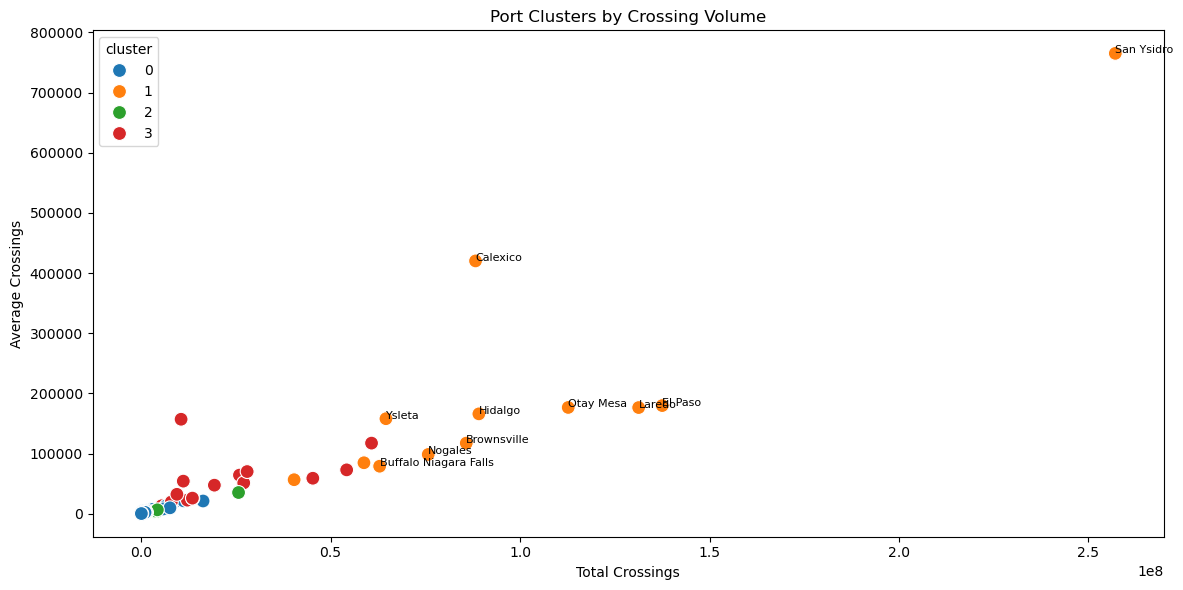

In [18]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=port_df,
    x="total_crossings",
    y="avg_crossings",
    hue="cluster",
    palette="tab10",
    s=100
)

# Label the biggest ports
for _, row in port_df.nlargest(10, "total_crossings").iterrows():
    plt.annotate(row["port_name"], 
                (row["total_crossings"], row["avg_crossings"]),
                fontsize=8, ha="left")

plt.title("Port Clusters by Crossing Volume")
plt.xlabel("Total Crossings")
plt.ylabel("Average Crossings")
plt.tight_layout()
plt.show()

In [20]:
# Save clustering results
port_df.to_csv("data/cleaned/port_clusters.csv", index=False)
print("Clustering results saved!")

# Final summary
print("\n── Cluster Summary ──")
summary = port_df.groupby("cluster").agg(
    num_ports                = ("port_name",              "count"),
    avg_total_crossings      = ("total_crossings",        "mean"),
    avg_monthly_crossings    = ("avg_crossings",          "mean"),
    avg_personal_ratio       = ("personal_vehicle_ratio", "mean"),
    avg_seasonality_variance = ("seasonality_variance",   "mean"),
    pct_mexico_border        = ("border_encoded",         "mean")
).round(3)
print(summary)

Clustering results saved!

── Cluster Summary ──
         num_ports  avg_total_crossings  avg_monthly_crossings  \
cluster                                                          
0               64         1.692926e+06               3264.758   
1               12         1.003459e+08             206511.714   
2               16         3.776488e+06               5420.334   
3               19         1.895222e+07              45646.753   

         avg_personal_ratio  avg_seasonality_variance  pct_mexico_border  
cluster                                                                   
0                     0.891                 14562.626               0.00  
1                     0.880                359277.564               0.75  
2                     0.514                 20508.583               0.00  
3                     0.964                 69758.229               1.00  


## Findings vs. Discovery Questions

### Q1: How do border crossing volumes correlate with seasonal trade cycles over time?

The `seasonality_variance` feature captures how much each port's monthly
crossing volume fluctuates across the year. Ports in the high-volume cluster
show the strongest seasonal swings, meaning the busiest ports are also the
most seasonally sensitive — likely driven by summer vacation travel and
holiday crossings rather than steady freight demand.

Ports in the small US-Canada clusters show much flatter year-round profiles,
consistent with freight and daily commuter traffic that does not follow
tourist or recreational cycles.

The EDA time series supports this — July and August consistently peak across
the dataset, February is the slowest month, and the seasonal pattern persisted
through and after the COVID-19 recovery, suggesting it is structural rather
than demand-driven.

### Q2: Are there identifiable shifts in trade flow between U.S.–Canada and
U.S.–Mexico crossings over time?

The clustering reveals a structural difference between the two borders rather
than a temporal shift. US-Mexico ports dominate the mid- and high-volume
clusters while US-Canada ports make up the low-volume clusters. Overall,
US-Mexico crossings account for approximately 4x the volume of US-Canada
crossings, consistent with the EDA finding.

The most significant finding for Q2 is the commercially-dominated US-Canada
cluster identified through the `personal_vehicle_ratio` feature. These ports
carry a disproportionate share of freight traffic relative to their crossing
volumes — a behavioral distinction that was invisible in the M2 model which
only used volume and border type. This suggests that while US-Mexico dominates
in passenger volume, US-Canada plays a larger role in commercial trade flow
than raw crossing counts imply.

The EDA shows no sustained directional shift between the two borders over the
observation period — both recovered from COVID-19 at similar rates and
maintained their relative proportions throughout.